In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("spotifyds.csv")
print(df)

       user_id    country  age signup_date   subscription_type  \
0            1     France   25  2021-08-19         Premium Duo   
1            2  Indonesia   20  2022-06-06      Premium Family   
2            3      Italy   53  2024-01-04  Premium Individual   
3            4      Italy   48  2018-08-26  Premium Individual   
4            5  Australia   18  2020-05-29                Free   
...        ...        ...  ...         ...                 ...   
49995    49996      India   33  2022-09-23                Free   
49996    49997      Italy   35  2023-11-17      Premium Family   
49997    49998     Brazil   33  2024-11-14  Premium Individual   
49998    49999        USA   43  2021-05-31                Free   
49999    50000  Indonesia   38  2024-07-05                Free   

      subscription_status  months_inactive  inactive_3_months_flag  \
0                  Active                0                       0   
1                  Active                0                       0 

In [4]:
df.head()
df.tail()

,user_id,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day
49995,49996,India,33,2022-09-23,Free,Active,2,0,Yes,No,5,11.83,Latin,Offline Mode,Concert Alerts,Tablet,8,5
49996,49997,Italy,35,2023-11-17,Premium Family,Active,0,0,No,No,4,8.01,Latin,Podcasts,Mood-based Auto Playlists,Car System,11,10
49997,49998,Brazil,33,2024-11-14,Premium Individual,Active,0,0,No,No,2,14.47,Rock,Lyrics,Lyrics Translation,Smart Speaker,9,13
49998,49999,USA,43,2021-05-31,Free,Active,0,0,No,No,5,21.86,Indie,AI DJ,Social Listening,Mobile,9,12
49999,50000,Indonesia,38,2024-07-05,Free,Inactive,3,1,No,No,5,13.30,Rock,Podcasts,Better AI Recommendations,Tablet,9,12


In [5]:
df.isnull().sum()

user_id                           0
country                           0
age                               0
signup_date                       0
subscription_type                 0
subscription_status               0
months_inactive                   0
inactive_3_months_flag            0
ad_interaction                    0
ad_conversion_to_subscription     0
music_suggestion_rating_1_to_5    0
avg_listening_hours_per_week      0
favorite_genre                    0
most_liked_feature                0
desired_future_feature            0
primary_device                    0
playlists_created                 0
avg_skips_per_day                 0
dtype: int64

In [6]:
import plotly.express as px

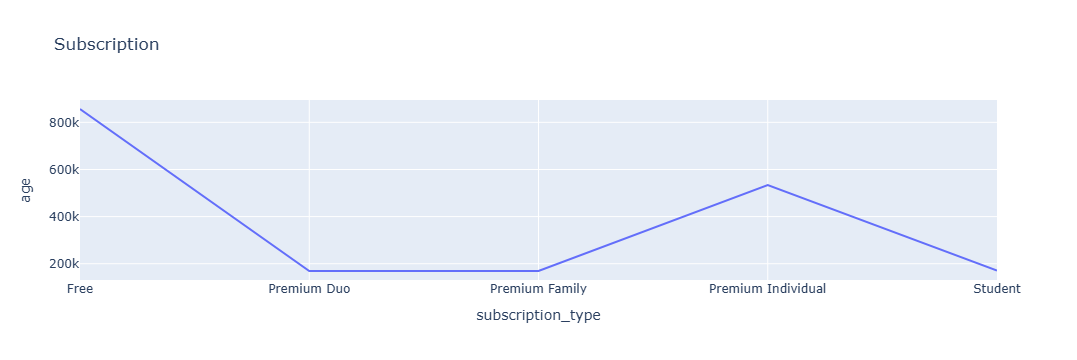

In [13]:
hrs = df.groupby('subscription_type')['age'].sum().reset_index()
fig = px.line(hrs, x='subscription_type' , y='age',title = 'Subscription')
fig.show()

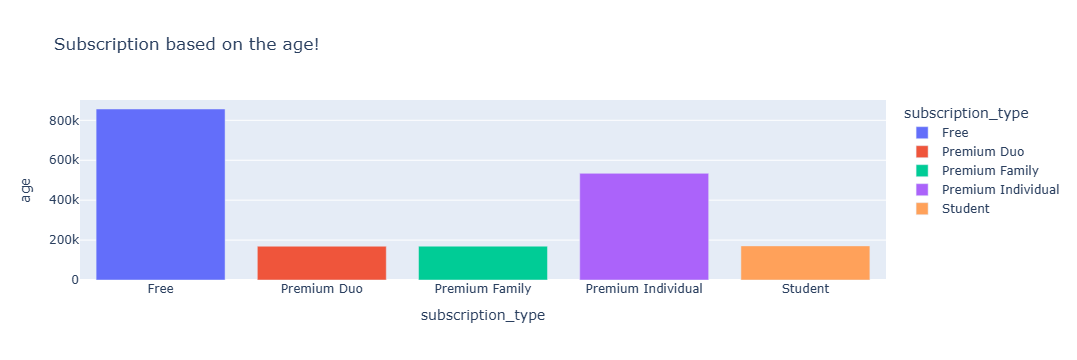

In [16]:
ageh = df.groupby('subscription_type')['age'].sum().reset_index()
fig = px.bar(ageh, x='subscription_type' , y='age',color='subscription_type',title = 'Subscription based on the age!')
fig.show()

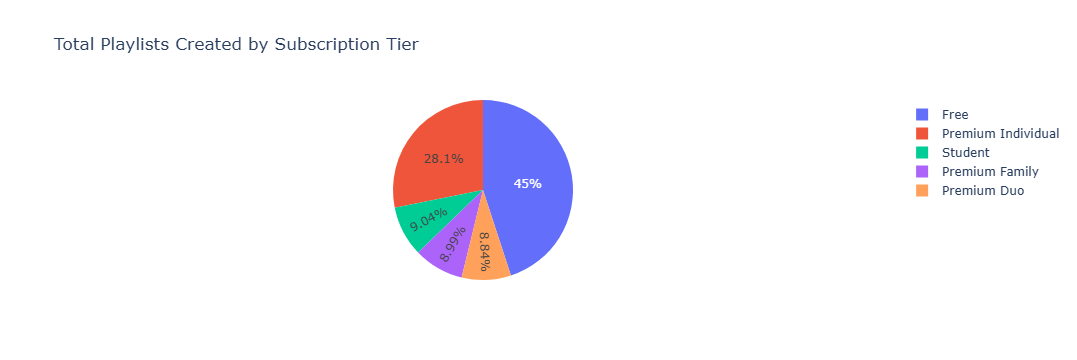

In [17]:
sub_playlists = df.groupby('subscription_type')['playlists_created'].sum().reset_index()
fig = px.pie(sub_playlists,names='subscription_type', values='playlists_created',title='Total Playlists Created by Subscription Tier')
fig.show()

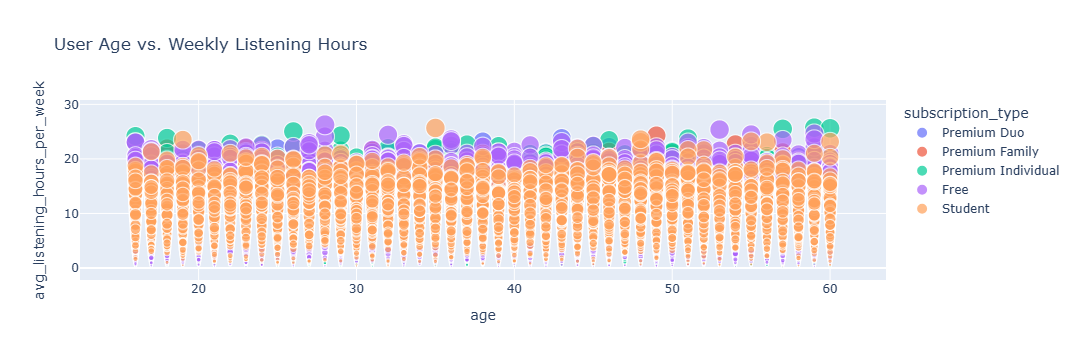

In [24]:
fig = px.scatter(df,x='age', y='avg_listening_hours_per_week',size='avg_listening_hours_per_week', color='subscription_type',title='User Age vs. Weekly Listening Hours')
fig.show()

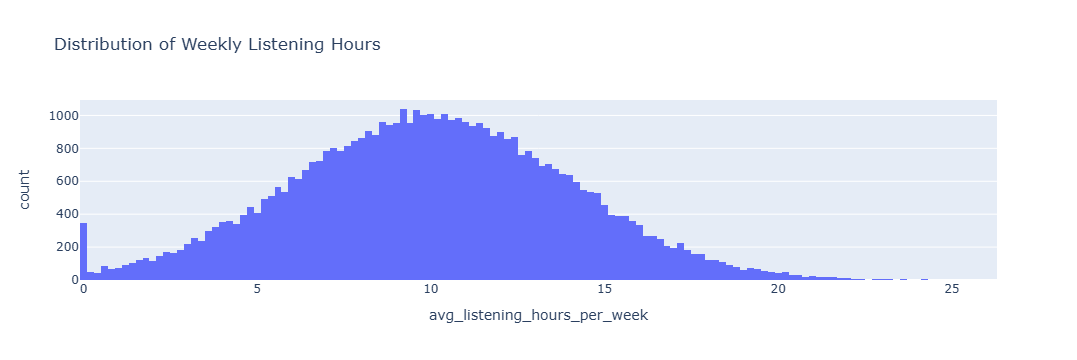

In [27]:
fig = px.histogram(df, x='avg_listening_hours_per_week',title='Distribution of Weekly Listening Hours')
fig.show()

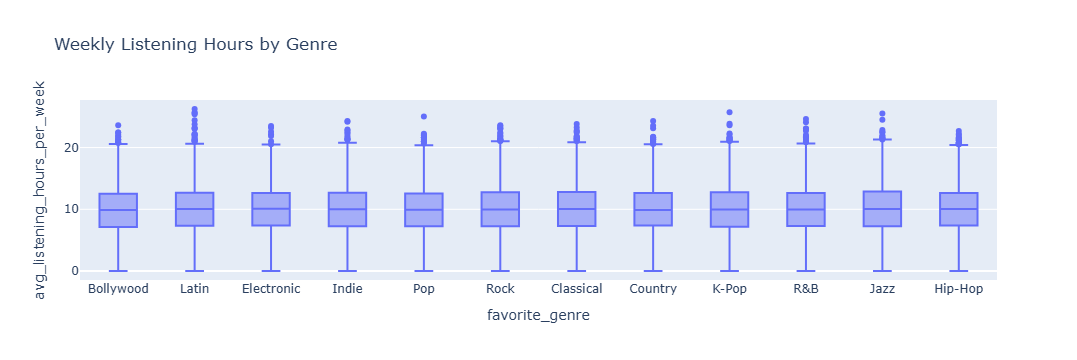

In [29]:
fig = px.box(df, x='favorite_genre', y='avg_listening_hours_per_week',title='Weekly Listening Hours by Genre')
fig.show()

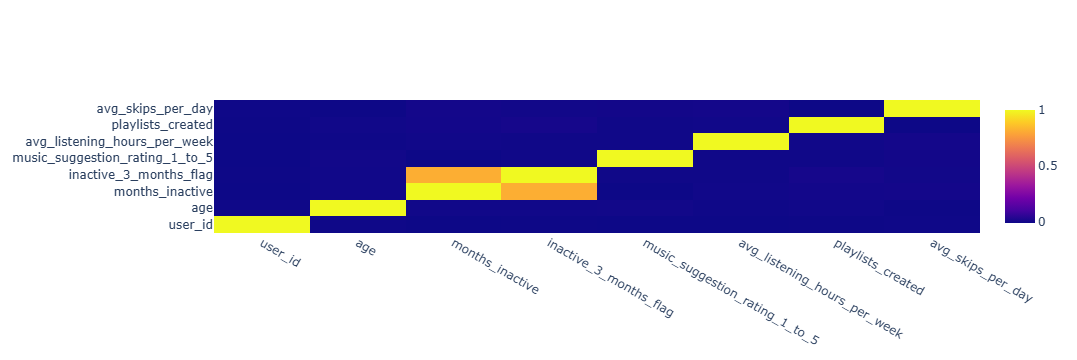

In [32]:
import plotly.graph_objects as go
corr = df.corr(numeric_only=True)
fig = go.Figure(data=go.Heatmap(z=corr,x=corr.columns,y=corr.index))
fig.show()